# Cluster Visualization for 100k Runs

这个 Notebook 默认读取当前项目目录下已经下载好的 5 份文件：

- `data/train.csv`
- `dbscan_clusters_parquet_100k/`
- `kmeans_centroids_json_100k/`
- `elkan_kmeans_centroids_json_100k/`
- `spark_ml_kmeans_100k_k11/`

图像包括：

- DBSCAN 聚类散点图
- 手写 K-Means 聚类散点图和质心
- Elkan K-Means 聚类散点图和质心
- Spark MLlib KMeans 聚类散点图和质心
- 三种 K-Means 质心对比图

表格包括：

- 三种 K-Means 的 centroid 汇总表
- 三种 K-Means 的 silhouette 汇总表

注意：

- 手写 `K-Means` 和 `Elkan K-Means` 当前只保存了质心，没有直接保存每个训练点的簇标签。
- 这里会在本地重新按照最近质心给样本分配类别，用于可视化和 silhouette 计算。
- silhouette 默认使用二维归一化特征，并在样本较大时做抽样近似计算。


In [2]:
# 如果本地环境缺少依赖，可以先运行这一格
# %pip install pandas pyarrow matplotlib numpy scikit-learn


In [3]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path("/Users/stevecheng/Desktop/MSBD5003/MSBD5003_Project/DBSCAN/Clustering_by_Spark")
TRAIN_CSV = PROJECT_ROOT / "data" / "train.csv"
DBSCAN_DIR = PROJECT_ROOT / "dbscan_clusters_parquet_100k"
KMEANS_DIR = PROJECT_ROOT / "kmeans_centroids_json_100k"
ELKAN_DIR = PROJECT_ROOT / "elkan_kmeans_centroids_json_100k"
SPARK_ML_KMEANS_DIR = PROJECT_ROOT / "spark_ml_kmeans_100k_k11"
SPARK_ML_CENTROIDS_DIR = SPARK_ML_KMEANS_DIR / "centroids_json"
SPARK_ML_ASSIGNMENTS_DIR = SPARK_ML_KMEANS_DIR / "assignments_parquet"
SPARK_ML_METRICS_DIR = SPARK_ML_KMEANS_DIR / "metrics_json"

TRAIN_LIMIT_FOR_100K_RUNS = 100_000
PLOT_SAMPLE_SIZE = 100_000
SILHOUETTE_SAMPLE_SIZE = 100_000
DBSCAN_TOP_CLUSTERS = 15
RANDOM_SEED = 42
SAVE_PLOTS = False
PLOTS_DIR = PROJECT_ROOT / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TRAIN_CSV exists:", TRAIN_CSV.exists())
print("DBSCAN_DIR exists:", DBSCAN_DIR.exists())
print("KMEANS_DIR exists:", KMEANS_DIR.exists())
print("ELKAN_DIR exists:", ELKAN_DIR.exists())
print("SPARK_ML_KMEANS_DIR exists:", SPARK_ML_KMEANS_DIR.exists())


PROJECT_ROOT: /Users/stevecheng/Desktop/MSBD5003/MSBD5003_Project/DBSCAN/Clustering_by_Spark
TRAIN_CSV exists: True
DBSCAN_DIR exists: True
KMEANS_DIR exists: True
ELKAN_DIR exists: True
SPARK_ML_KMEANS_DIR exists: True


In [4]:
def filter_train_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    filtered = df[
        (df["pickup_longitude"] > -74.25)
        & (df["pickup_longitude"] < -73.7)
        & (df["pickup_latitude"] > 40.5)
        & (df["pickup_latitude"] < 40.9)
        & (df["passenger_count"] > 0)
    ].copy()
    return filtered.reset_index(drop=True)


def compute_scaler_bounds(df: pd.DataFrame) -> dict:
    lon_min = df["pickup_longitude"].min()
    lon_max = df["pickup_longitude"].max()
    lat_min = df["pickup_latitude"].min()
    lat_max = df["pickup_latitude"].max()
    return {
        "lon_min": lon_min,
        "lon_max": lon_max,
        "lat_min": lat_min,
        "lat_max": lat_max,
    }


def add_scaled_coordinates(df: pd.DataFrame, bounds: dict) -> pd.DataFrame:
    result = df.copy()
    lon_range = bounds["lon_max"] - bounds["lon_min"]
    lat_range = bounds["lat_max"] - bounds["lat_min"]
    if lon_range == 0:
        lon_range = 1e-9
    if lat_range == 0:
        lat_range = 1e-9

    result["scaled_longitude"] = (result["pickup_longitude"] - bounds["lon_min"]) / lon_range
    result["scaled_latitude"] = (result["pickup_latitude"] - bounds["lat_min"]) / lat_range
    return result


def inverse_scale_centroids(df: pd.DataFrame, bounds: dict) -> pd.DataFrame:
    result = df.copy()
    result["pickup_longitude"] = result["scaled_longitude"] * (bounds["lon_max"] - bounds["lon_min"]) + bounds["lon_min"]
    result["pickup_latitude"] = result["scaled_latitude"] * (bounds["lat_max"] - bounds["lat_min"]) + bounds["lat_min"]
    return result


def load_centroids(directory: Path) -> pd.DataFrame:
    records = []
    for path in sorted(directory.glob("part-*.json")):
        with path.open() as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                obj = json.loads(line)
                centroid = json.loads(obj["centroid"])
                records.append(
                    {
                        "cluster_id": int(obj["cluster_id"]),
                        "scaled_longitude": float(centroid[0]),
                        "scaled_latitude": float(centroid[1]),
                    }
                )

    if not records:
        raise FileNotFoundError(f"No centroid JSON parts found in {directory}")

    return pd.DataFrame(records).sort_values("cluster_id").reset_index(drop=True)


def load_parquet_parts(directory: Path) -> pd.DataFrame:
    parquet_parts = sorted(directory.glob("part-*.parquet"))
    if not parquet_parts:
        raise FileNotFoundError(f"No parquet parts found in {directory}")
    frames = [pd.read_parquet(path) for path in parquet_parts]
    return pd.concat(frames, ignore_index=True)


def load_dbscan_labels(directory: Path) -> pd.DataFrame:
    result = load_parquet_parts(directory)
    result["point_id"] = result["point_id"].astype(str)
    result["cluster_id"] = result["cluster_id"].astype(str)
    return result


def load_spark_ml_assignments(directory: Path) -> pd.DataFrame:
    result = load_parquet_parts(directory)
    result["point_id"] = result["point_id"].astype(str)
    result["cluster_id"] = result["cluster_id"].astype(int)
    return result


def load_metrics_json(directory: Path) -> pd.DataFrame:
    records = []
    for path in sorted(directory.glob("part-*.json")):
        with path.open() as f:
            for line in f:
                line = line.strip()
                if line:
                    records.append(json.loads(line))
    if not records:
        raise FileNotFoundError(f"No metric JSON parts found in {directory}")
    return pd.DataFrame(records)


def assign_nearest_centroid(points_df: pd.DataFrame, centroids_df: pd.DataFrame, label_col: str) -> pd.DataFrame:
    points = points_df[["scaled_longitude", "scaled_latitude"]].to_numpy()
    centroids = centroids_df[["scaled_longitude", "scaled_latitude"]].to_numpy()
    distances = np.sum((points[:, None, :] - centroids[None, :, :]) ** 2, axis=2)
    labels = np.argmin(distances, axis=1)
    result = points_df.copy()
    result[label_col] = labels.astype(int)
    return result


def sample_for_plot(df: pd.DataFrame, n: int) -> pd.DataFrame:
    if len(df) <= n:
        return df.copy()
    return df.sample(n=n, random_state=RANDOM_SEED).copy()


def plot_cluster_scatter(ax, df: pd.DataFrame, cluster_col: str, title: str, centroids_df: pd.DataFrame | None = None):
    cluster_values = list(pd.unique(df[cluster_col]))
    cmap = plt.get_cmap("tab20", max(len(cluster_values), 1))
    color_lookup = {cluster: cmap(i % max(len(cluster_values), 1)) for i, cluster in enumerate(sorted(cluster_values))}

    for cluster in sorted(cluster_values):
        cluster_df = df[df[cluster_col] == cluster]
        ax.scatter(
            cluster_df["pickup_longitude"],
            cluster_df["pickup_latitude"],
            s=6,
            alpha=0.55,
            color=color_lookup[cluster],
            label=str(cluster),
        )

    if centroids_df is not None:
        ax.scatter(
            centroids_df["pickup_longitude"],
            centroids_df["pickup_latitude"],
            s=180,
            marker="X",
            color="black",
            edgecolor="white",
            linewidth=1.2,
            label="centroid",
        )

    ax.set_title(title)
    ax.set_xlabel("pickup_longitude")
    ax.set_ylabel("pickup_latitude")
    ax.legend(loc="best", fontsize=8, ncols=2)


def maybe_save(fig, filename: str):
    if SAVE_PLOTS:
        fig.savefig(PLOTS_DIR / filename, dpi=200, bbox_inches="tight")


def build_centroid_series(centroids_df: pd.DataFrame, longitude_col: str, latitude_col: str) -> pd.Series:
    ordered_df = centroids_df.sort_values("cluster_id").copy()
    ordered_df["cluster_name"] = "cluster_" + ordered_df["cluster_id"].astype(int).astype(str)
    ordered_df["centroid"] = list(
        zip(
            ordered_df[longitude_col].round(6),
            ordered_df[latitude_col].round(6),
        )
    )
    return ordered_df.set_index("cluster_name")["centroid"]


def compute_silhouette_summary(algorithm_name: str, df: pd.DataFrame, cluster_col: str) -> dict:
    feature_array = df[["scaled_longitude", "scaled_latitude"]].to_numpy()
    labels = df[cluster_col].to_numpy()
    unique_labels = pd.unique(labels)
    if len(unique_labels) < 2:
        score = np.nan
    else:
        sample_size = min(SILHOUETTE_SAMPLE_SIZE, len(df))
        score = silhouette_score(
            feature_array,
            labels,
            metric="euclidean",
            sample_size=sample_size,
            random_state=RANDOM_SEED,
        )
    return {
        "algorithm": algorithm_name,
        "k": int(len(unique_labels)),
        "n_points": int(len(df)),
        "silhouette_sample_size": int(min(SILHOUETTE_SAMPLE_SIZE, len(df))),
        "silhouette_score": float(score) if pd.notna(score) else np.nan,
    }


In [5]:
train_df = pd.read_csv(
    TRAIN_CSV,
    usecols=["id", "pickup_longitude", "pickup_latitude", "passenger_count"],
)
filtered_train_df = filter_train_dataframe(train_df)
bounds = compute_scaler_bounds(filtered_train_df)
scaled_train_df = add_scaled_coordinates(filtered_train_df, bounds)

train_100k_df = scaled_train_df.iloc[:TRAIN_LIMIT_FOR_100K_RUNS].copy()
dbscan_labels_df = load_dbscan_labels(DBSCAN_DIR)
kmeans_centroids_scaled_df = load_centroids(KMEANS_DIR)
elkan_centroids_scaled_df = load_centroids(ELKAN_DIR)
spark_ml_centroids_scaled_df = load_centroids(SPARK_ML_CENTROIDS_DIR)
spark_ml_assignments_df = load_spark_ml_assignments(SPARK_ML_ASSIGNMENTS_DIR)
spark_ml_metrics_df = load_metrics_json(SPARK_ML_METRICS_DIR)

kmeans_centroids_raw_df = inverse_scale_centroids(kmeans_centroids_scaled_df, bounds)
elkan_centroids_raw_df = inverse_scale_centroids(elkan_centroids_scaled_df, bounds)
spark_ml_centroids_raw_df = inverse_scale_centroids(spark_ml_centroids_scaled_df, bounds)

dbscan_points_df = train_100k_df.merge(dbscan_labels_df, left_on="id", right_on="point_id", how="inner")
kmeans_labeled_df = assign_nearest_centroid(train_100k_df, kmeans_centroids_scaled_df, "kmeans_cluster")
elkan_labeled_df = assign_nearest_centroid(train_100k_df, elkan_centroids_scaled_df, "elkan_cluster")
spark_ml_labeled_df = train_100k_df.merge(spark_ml_assignments_df, left_on="id", right_on="point_id", how="inner")

print(f"Filtered train size: {len(filtered_train_df):,}")
print(f"100k subset size used for local visualization: {len(train_100k_df):,}")
print(f"DBSCAN assigned points: {len(dbscan_points_df):,}")
print(f"DBSCAN unique clusters: {dbscan_points_df['cluster_id'].nunique():,}")
print(f"Spark ML assigned points: {len(spark_ml_labeled_df):,}")
print(f"Spark ML unique clusters: {spark_ml_labeled_df['cluster_id'].nunique():,}")
display(spark_ml_metrics_df)


Filtered train size: 1,458,251
100k subset size used for local visualization: 100,000
DBSCAN assigned points: 99,268
DBSCAN unique clusters: 11
Spark ML assigned points: 100,000
Spark ML unique clusters: 11


,algorithm,k,max_iterations,tol,seed,init_mode,limit,test_mode,training_cost,silhouette_score,cluster_sizes
0,pyspark.ml.clustering.KMeans,11,20,0.0001,42,k-means||,100000,False,58.957473,0.526063,"[{""cluster_id"": 0, ""count"": 20857}, {""cluster_..."


,cluster_id,count
0,35_44_C1,92264
1,60_61_C1,2551
2,77_29_C1,2109
3,39_38_C1,899
4,47_54_C1,595
5,45_46_C1,483
6,51_54_C1,206
7,47_41_C1,63
8,51_43_C1,40
9,59_55_C1,37


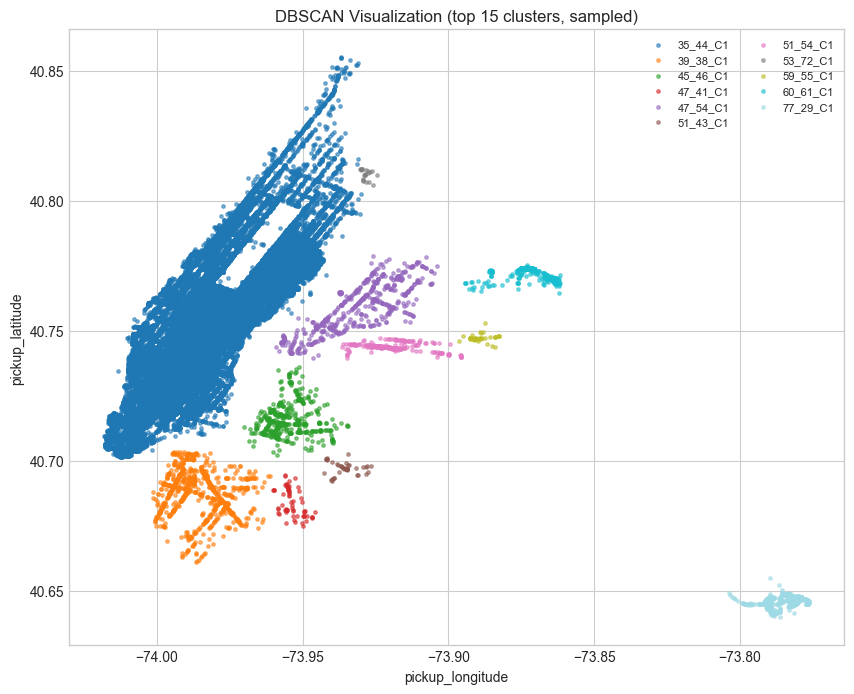

In [6]:
dbscan_cluster_sizes = (
    dbscan_points_df.groupby("cluster_id").size().sort_values(ascending=False).rename("count").reset_index()
)
top_dbscan_clusters = dbscan_cluster_sizes.head(DBSCAN_TOP_CLUSTERS)["cluster_id"].tolist()
dbscan_plot_df = dbscan_points_df[dbscan_points_df["cluster_id"].isin(top_dbscan_clusters)].copy()
dbscan_plot_df = sample_for_plot(dbscan_plot_df, PLOT_SAMPLE_SIZE)

display(dbscan_cluster_sizes.head(20))

fig, ax = plt.subplots(figsize=(10, 8))
plot_cluster_scatter(
    ax,
    dbscan_plot_df,
    cluster_col="cluster_id",
    title=f"DBSCAN Visualization (top {DBSCAN_TOP_CLUSTERS} clusters, sampled)",
)
maybe_save(fig, "dbscan_visualization_100k.png")
plt.show()


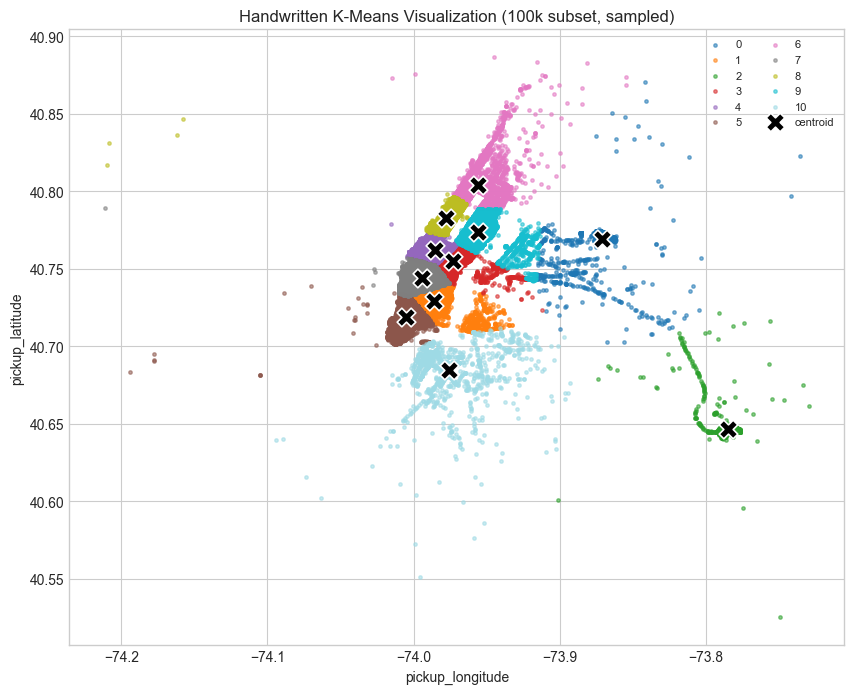

In [7]:
kmeans_plot_df = sample_for_plot(kmeans_labeled_df, PLOT_SAMPLE_SIZE)

fig, ax = plt.subplots(figsize=(10, 8))
plot_cluster_scatter(
    ax,
    kmeans_plot_df,
    cluster_col="kmeans_cluster",
    title="Handwritten K-Means Visualization (100k subset, sampled)",
    centroids_df=kmeans_centroids_raw_df,
)
maybe_save(fig, "kmeans_visualization_100k.png")
plt.show()


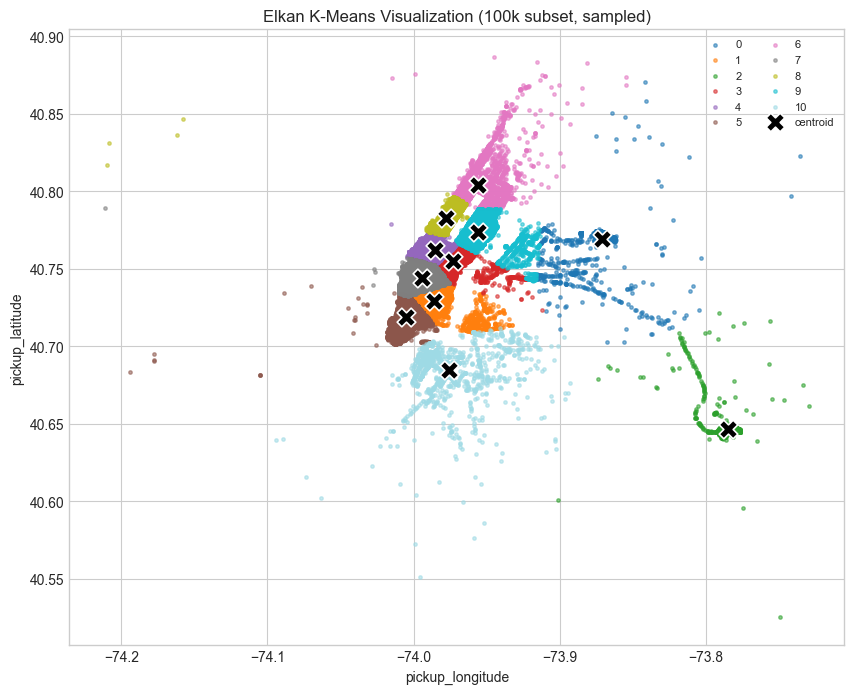

In [8]:
elkan_plot_df = sample_for_plot(elkan_labeled_df, PLOT_SAMPLE_SIZE)

fig, ax = plt.subplots(figsize=(10, 8))
plot_cluster_scatter(
    ax,
    elkan_plot_df,
    cluster_col="elkan_cluster",
    title="Elkan K-Means Visualization (100k subset, sampled)",
    centroids_df=elkan_centroids_raw_df,
)
maybe_save(fig, "elkan_visualization_100k.png")
plt.show()


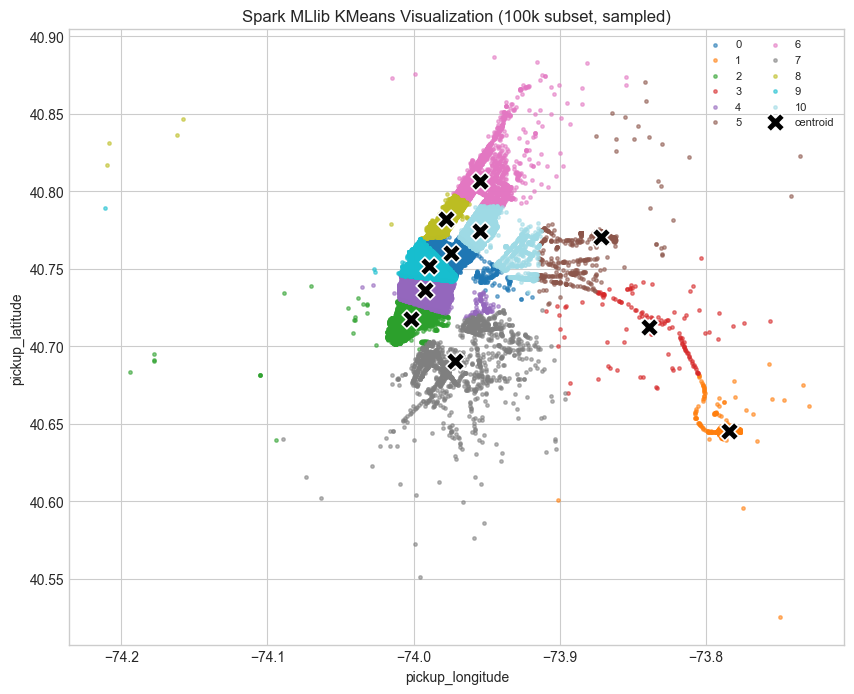

In [9]:
spark_ml_plot_df = sample_for_plot(spark_ml_labeled_df, PLOT_SAMPLE_SIZE)

fig, ax = plt.subplots(figsize=(10, 8))
plot_cluster_scatter(
    ax,
    spark_ml_plot_df,
    cluster_col="cluster_id",
    title="Spark MLlib KMeans Visualization (100k subset, sampled)",
    centroids_df=spark_ml_centroids_raw_df,
)
maybe_save(fig, "spark_ml_kmeans_visualization_100k_k11.png")
plt.show()


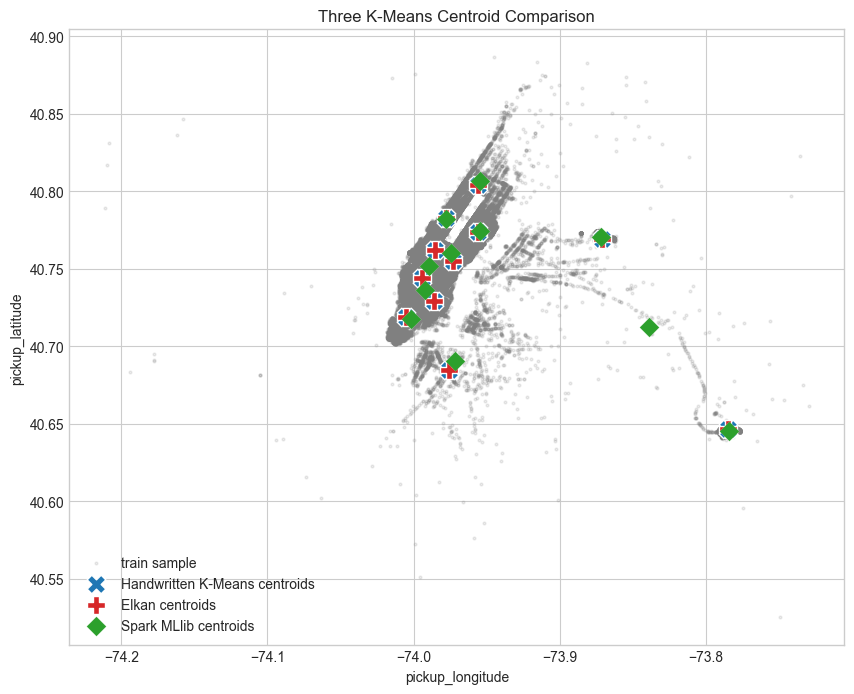

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
background_df = sample_for_plot(train_100k_df, PLOT_SAMPLE_SIZE)
ax.scatter(background_df["pickup_longitude"], background_df["pickup_latitude"], s=4, alpha=0.15, color="gray", label="train sample")
ax.scatter(
    kmeans_centroids_raw_df["pickup_longitude"],
    kmeans_centroids_raw_df["pickup_latitude"],
    s=180,
    marker="X",
    color="tab:blue",
    edgecolor="white",
    linewidth=1.0,
    label="Handwritten K-Means centroids",
)
ax.scatter(
    elkan_centroids_raw_df["pickup_longitude"],
    elkan_centroids_raw_df["pickup_latitude"],
    s=180,
    marker="P",
    color="tab:red",
    edgecolor="white",
    linewidth=1.0,
    label="Elkan centroids",
)
ax.scatter(
    spark_ml_centroids_raw_df["pickup_longitude"],
    spark_ml_centroids_raw_df["pickup_latitude"],
    s=100,
    marker="D",
    color="tab:green",
    edgecolor="white",
    linewidth=0.1,
    label="Spark MLlib centroids",
)
ax.set_title("Three K-Means Centroid Comparison")
ax.set_xlabel("pickup_longitude")
ax.set_ylabel("pickup_latitude")
ax.legend(loc="best")
maybe_save(fig, "three_kmeans_centroid_comparison.png")
plt.show()


In [11]:
centroid_summary_df = pd.concat(
    [
        build_centroid_series(kmeans_centroids_scaled_df, "scaled_longitude", "scaled_latitude").rename("handwritten_kmeans_scaled"),
        build_centroid_series(elkan_centroids_scaled_df, "scaled_longitude", "scaled_latitude").rename("elkan_kmeans_scaled"),
        build_centroid_series(spark_ml_centroids_scaled_df, "scaled_longitude", "scaled_latitude").rename("spark_ml_kmeans_scaled"),
        build_centroid_series(kmeans_centroids_raw_df, "pickup_longitude", "pickup_latitude").rename("handwritten_kmeans"),
        build_centroid_series(elkan_centroids_raw_df, "pickup_longitude", "pickup_latitude").rename("elkan_kmeans"),
        build_centroid_series(spark_ml_centroids_raw_df, "pickup_longitude", "pickup_latitude").rename("spark_ml_kmeans"),
    ],
    axis=1,
)
centroid_summary_df.index.name = "cluster"
display(centroid_summary_df)


,handwritten_kmeans_scaled,elkan_kmeans_scaled,spark_ml_kmeans_scaled,handwritten_kmeans,elkan_kmeans,spark_ml_kmeans
cluster,,,,,,
cluster_0,"(0.684114, 0.669435)","(0.684114, 0.669435)","(0.489067, 0.645858)","(-73.87106, 40.76946)","(-73.87106, 40.76946)","(-73.974474, 40.760192)"
cluster_1,"(0.467397, 0.566415)","(0.467397, 0.566415)","(0.847493, 0.354608)","(-73.985964, 40.728961)","(-73.985964, 40.728961)","(-73.784435, 40.645696)"
cluster_2,"(0.846221, 0.357291)","(0.846221, 0.357291)","(0.43719, 0.538277)","(-73.78511, 40.646751)","(-73.78511, 40.646751)","(-74.00198, 40.717899)"
cluster_3,"(0.492415, 0.631895)","(0.492415, 0.631895)","(0.744278, 0.524784)","(-73.972699, 40.754702)","(-73.972699, 40.754702)","(-73.83916, 40.712595)"
cluster_4,"(0.469264, 0.651022)","(0.469264, 0.651022)","(0.455186, 0.584504)","(-73.984974, 40.762221)","(-73.984974, 40.762221)","(-73.992438, 40.736072)"
cluster_5,"(0.431493, 0.54094)","(0.431493, 0.54094)","(0.683359, 0.672299)","(-74.005, 40.718946)","(-74.005, 40.718946)","(-73.87146, 40.770586)"
cluster_6,"(0.524229, 0.757459)","(0.524229, 0.757459)","(0.526485, 0.763447)","(-73.955831, 40.804063)","(-73.955831, 40.804063)","(-73.954635, 40.806418)"
cluster_7,"(0.452187, 0.605508)","(0.452187, 0.605508)","(0.495046, 0.46904)","(-73.994028, 40.744329)","(-73.994028, 40.744329)","(-73.971304, 40.690681)"
cluster_8,"(0.482628, 0.703055)","(0.482628, 0.703055)","(0.482352, 0.701852)","(-73.977888, 40.782676)","(-73.977888, 40.782676)","(-73.978034, 40.782204)"


In [12]:
silhouette_summary_df = pd.DataFrame(
    [
        compute_silhouette_summary("handwritten_kmeans", kmeans_labeled_df, "kmeans_cluster"),
        compute_silhouette_summary("elkan_kmeans", elkan_labeled_df, "elkan_cluster"),
        compute_silhouette_summary("spark_ml_kmeans", spark_ml_labeled_df.rename(columns={"cluster_id": "spark_ml_cluster"}), "spark_ml_cluster"),
    ]
)
silhouette_summary_df = silhouette_summary_df.sort_values("algorithm").reset_index(drop=True)
display(silhouette_summary_df)


,algorithm,k,n_points,silhouette_sample_size,silhouette_score
0,elkan_kmeans,11,100000,100000,0.387149
1,handwritten_kmeans,11,100000,100000,0.387149
2,spark_ml_kmeans,11,100000,100000,0.383364


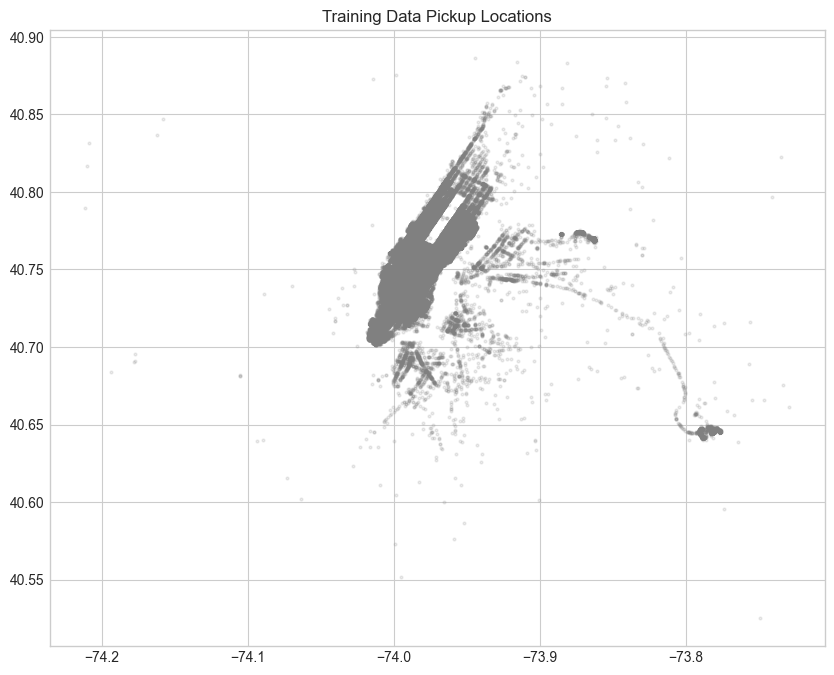

In [13]:
# Visualize all pickup points without showing clustering labels
# Recommended: use filtered_train_df, because it is exactly the full dataset used by clustering.
# If you want the raw unfiltered rows from train.csv, replace filtered_train_df with train_df.


fig, ax = plt.subplots(figsize=(10, 8))
ax.set_title("Training Data Pickup Locations")
background_df = sample_for_plot(train_100k_df, PLOT_SAMPLE_SIZE)
ax.scatter(background_df["pickup_longitude"], background_df["pickup_latitude"], s=4, alpha=0.15, color="gray", label="train sample")



In [32]:
# Local single-machine DBSCAN baseline on 100 processed points
# This uses sklearn's in-memory DBSCAN to give a quick speed reference.

from time import perf_counter
from sklearn.cluster import DBSCAN

LOCAL_DBSCAN_SAMPLE_SIZE = 100000
LOCAL_DBSCAN_EPS = 0.02
LOCAL_DBSCAN_MIN_SAMPLES = 20

local_dbscan_input_df = scaled_train_df.iloc[:LOCAL_DBSCAN_SAMPLE_SIZE].copy()
local_dbscan_features = local_dbscan_input_df[["scaled_longitude", "scaled_latitude"]].to_numpy()

start_time = perf_counter()
local_dbscan_model = DBSCAN(eps=LOCAL_DBSCAN_EPS, min_samples=LOCAL_DBSCAN_MIN_SAMPLES, metric="euclidean")
local_dbscan_labels = local_dbscan_model.fit_predict(local_dbscan_features)
elapsed_seconds = perf_counter() - start_time

local_dbscan_result_df = local_dbscan_input_df[["id", "pickup_longitude", "pickup_latitude", "scaled_longitude", "scaled_latitude"]].copy()
local_dbscan_result_df["dbscan_cluster"] = local_dbscan_labels

cluster_size_df = (
    pd.Series(local_dbscan_labels, name="dbscan_cluster")
    .value_counts(dropna=False)
    .rename_axis("dbscan_cluster")
    .reset_index(name="count")
    .sort_values("dbscan_cluster")
    .reset_index(drop=True)
)

n_noise_points = int((local_dbscan_labels == -1).sum())
n_clusters = int(len(set(local_dbscan_labels)) - (1 if -1 in local_dbscan_labels else 0))

print(f"Local DBSCAN input size: {len(local_dbscan_input_df):,}")
print(f"eps={LOCAL_DBSCAN_EPS}, min_samples={LOCAL_DBSCAN_MIN_SAMPLES}")
print(f"Elapsed time: {elapsed_seconds:.6f} seconds")
print(f"Clusters found (excluding noise): {n_clusters}")
print(f"Noise points: {n_noise_points}")

display(cluster_size_df)
display(local_dbscan_result_df.head(10))


Local DBSCAN input size: 100,000
eps=0.02, min_samples=20
Elapsed time: 15.318183 seconds
Clusters found (excluding noise): 2
Noise points: 357


,dbscan_cluster,count
0,-1,357
1,0,97495
2,1,2148


,id,pickup_longitude,pickup_latitude,scaled_longitude,scaled_latitude,dbscan_cluster
0,id2875421,-73.982155,40.767937,0.474581,0.665560,0
1,id2377394,-73.980415,40.738564,0.477862,0.590842,0
2,id3858529,-73.979027,40.763939,0.480481,0.655391,0
3,id3504673,-74.010040,40.719971,0.421987,0.543546,0
4,id2181028,-73.973053,40.793209,0.491748,0.729848,0
5,id0801584,-73.982857,40.742195,0.473257,0.600080,0
6,id1813257,-73.969017,40.757839,0.499360,0.639875,0
7,id1324603,-73.969276,40.797779,0.498870,0.741473,0
8,id1301050,-73.999481,40.738400,0.441902,0.590424,0
9,id0012891,-73.981049,40.744339,0.476667,0.605533,0


In [24]:
from time import perf_counter
import numpy as np
import pandas as pd

# Local single-machine manual KMeans baseline

LOCAL_KMEANS_SAMPLE_SIZE = 100000
LOCAL_KMEANS_N_CLUSTERS = 11
LOCAL_KMEANS_MAX_ITER = 100
LOCAL_KMEANS_TOL = 1e-6
LOCAL_KMEANS_RANDOM_STATE = 42

local_kmeans_input_df = scaled_train_df.iloc[:LOCAL_KMEANS_SAMPLE_SIZE].copy()

X = local_kmeans_input_df[
    ["scaled_longitude", "scaled_latitude"]
].to_numpy(dtype=np.float64)

n_samples, n_features = X.shape
k = LOCAL_KMEANS_N_CLUSTERS

rng = np.random.default_rng(LOCAL_KMEANS_RANDOM_STATE)

# 1. Randomly initialize centroids from existing points
init_indices = rng.choice(n_samples, size=k, replace=False)
centroids = X[init_indices].copy()

start_time = perf_counter()

for it in range(LOCAL_KMEANS_MAX_ITER):
    # 2. Compute squared Euclidean distance to each centroid
    # distances shape: [n_samples, k]
    distances = np.sum((X[:, None, :] - centroids[None, :, :]) ** 2, axis=2)

    # 3. Assign each point to nearest centroid
    labels = np.argmin(distances, axis=1)

    # 4. Update centroids
    new_centroids = np.empty_like(centroids)

    for cluster_id in range(k):
        cluster_points = X[labels == cluster_id]

        if len(cluster_points) == 0:
            # If a cluster becomes empty, reinitialize it randomly
            new_centroids[cluster_id] = X[rng.integers(0, n_samples)]
        else:
            new_centroids[cluster_id] = cluster_points.mean(axis=0)

    # 5. Check convergence
    centroid_shift = np.linalg.norm(new_centroids - centroids)

    centroids = new_centroids

    if centroid_shift < LOCAL_KMEANS_TOL:
        break

elapsed_seconds = perf_counter() - start_time

# Final inertia: sum of squared distances to assigned centroid
final_distances = np.sum((X - centroids[labels]) ** 2, axis=1)
inertia = final_distances.sum()

local_kmeans_result_df = local_kmeans_input_df[
    ["id", "pickup_longitude", "pickup_latitude", "scaled_longitude", "scaled_latitude"]
].copy()

local_kmeans_result_df["kmeans_cluster"] = labels

cluster_size_df = (
    pd.Series(labels, name="kmeans_cluster")
    .value_counts(dropna=False)
    .rename_axis("kmeans_cluster")
    .reset_index(name="count")
    .sort_values("kmeans_cluster")
    .reset_index(drop=True)
)

centroid_df = pd.DataFrame(
    centroids,
    columns=["centroid_scaled_longitude", "centroid_scaled_latitude"]
)
centroid_df["kmeans_cluster"] = np.arange(k)
centroid_df = centroid_df[
    ["kmeans_cluster", "centroid_scaled_longitude", "centroid_scaled_latitude"]
]

print(f"Local manual KMeans input size: {len(local_kmeans_input_df):,}")
print(f"n_clusters={LOCAL_KMEANS_N_CLUSTERS}")
print(f"max_iter={LOCAL_KMEANS_MAX_ITER}, actual_iter={it + 1}")
print(f"Elapsed time: {elapsed_seconds:.6f} seconds")
print(f"Inertia: {inertia:.6f}")

display(cluster_size_df)
display(centroid_df)
display(local_kmeans_result_df.head(10))

Local manual KMeans input size: 100,000
n_clusters=11
max_iter=100, actual_iter=100
Elapsed time: 1.102002 seconds
Inertia: 57.604527


,kmeans_cluster,count
0,0,2901
1,1,11681
2,2,2503
3,3,16781
4,4,13074
5,5,12518
6,6,7000
7,7,12372
8,8,2234
9,9,5170


,kmeans_cluster,centroid_scaled_longitude,centroid_scaled_latitude
0,0,0.683965,0.668999
1,1,0.526635,0.686465
2,2,0.529634,0.768795
3,3,0.470710,0.614435
4,4,0.501550,0.645589
5,5,0.458062,0.555831
6,6,0.485411,0.707868
7,7,0.443303,0.592787
8,8,0.845446,0.357351
9,9,0.433839,0.503507


,id,pickup_longitude,pickup_latitude,scaled_longitude,scaled_latitude,kmeans_cluster
0,id2875421,-73.982155,40.767937,0.474581,0.665560,10
1,id2377394,-73.980415,40.738564,0.477862,0.590842,3
2,id3858529,-73.979027,40.763939,0.480481,0.655391,10
3,id3504673,-74.010040,40.719971,0.421987,0.543546,5
4,id2181028,-73.973053,40.793209,0.491748,0.729848,6
5,id0801584,-73.982857,40.742195,0.473257,0.600080,3
6,id1813257,-73.969017,40.757839,0.499360,0.639875,4
7,id1324603,-73.969276,40.797779,0.498870,0.741473,6
8,id1301050,-73.999481,40.738400,0.441902,0.590424,7
9,id0012891,-73.981049,40.744339,0.476667,0.605533,3


Local DBSCAN input size: 100,000
eps=0.01, min_samples=20
Elapsed time: 4.177342 seconds
Clusters found excluding noise: 14
Noise points: 732


,dbscan_cluster,count
0,-1,732
1,0,92264
2,1,483
3,2,2435
4,3,2109
5,4,595
6,5,116
7,6,184
8,7,899
9,8,28


,id,pickup_longitude,pickup_latitude,scaled_longitude,scaled_latitude,dbscan_cluster
0,id2875421,-73.982155,40.767937,0.474581,0.665560,0
1,id2377394,-73.980415,40.738564,0.477862,0.590842,0
2,id3858529,-73.979027,40.763939,0.480481,0.655391,0
3,id3504673,-74.010040,40.719971,0.421987,0.543546,0
4,id2181028,-73.973053,40.793209,0.491748,0.729848,0
5,id0801584,-73.982857,40.742195,0.473257,0.600080,0
6,id1813257,-73.969017,40.757839,0.499360,0.639875,0
7,id1324603,-73.969276,40.797779,0.498870,0.741473,0
8,id1301050,-73.999481,40.738400,0.441902,0.590424,0
9,id0012891,-73.981049,40.744339,0.476667,0.605533,0


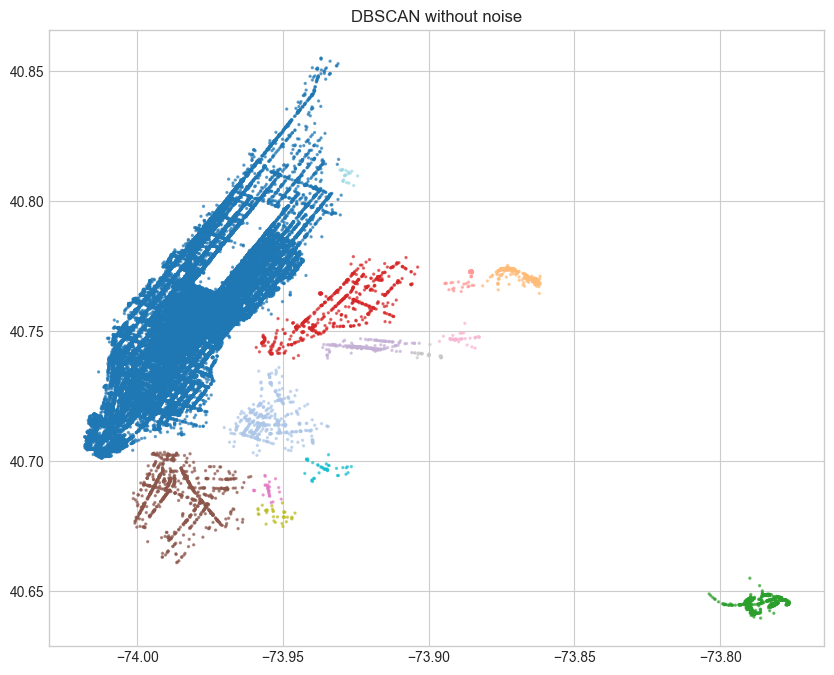

In [51]:
# Local single-machine DBSCAN baseline + plot
# This uses sklearn's in-memory DBSCAN to give a quick speed/reference result.

import pandas as pd
import matplotlib.pyplot as plt
from time import perf_counter
from sklearn.cluster import DBSCAN

# -----------------------------
# 1. Parameters
# -----------------------------
LOCAL_DBSCAN_SAMPLE_SIZE = 100000
LOCAL_DBSCAN_EPS = 0.01
LOCAL_DBSCAN_MIN_SAMPLES = 20

# -----------------------------
# 2. Prepare input
# -----------------------------
local_dbscan_input_df = scaled_train_df.iloc[:LOCAL_DBSCAN_SAMPLE_SIZE].copy()

local_dbscan_features = local_dbscan_input_df[
    ["scaled_longitude", "scaled_latitude"]
].to_numpy()

# -----------------------------
# 3. Run DBSCAN
# -----------------------------
start_time = perf_counter()

local_dbscan_model = DBSCAN(
    eps=LOCAL_DBSCAN_EPS,
    min_samples=LOCAL_DBSCAN_MIN_SAMPLES,
    metric="euclidean"
)

local_dbscan_labels = local_dbscan_model.fit_predict(local_dbscan_features)

elapsed_seconds = perf_counter() - start_time

# -----------------------------
# 4. Build result DataFrame
# -----------------------------
local_dbscan_result_df = local_dbscan_input_df[
    [
        "id",
        "pickup_longitude",
        "pickup_latitude",
        "scaled_longitude",
        "scaled_latitude"
    ]
].copy()

local_dbscan_result_df["dbscan_cluster"] = local_dbscan_labels

# -----------------------------
# 5. Cluster statistics
# -----------------------------
cluster_size_df = (
    pd.Series(local_dbscan_labels, name="dbscan_cluster")
    .value_counts(dropna=False)
    .rename_axis("dbscan_cluster")
    .reset_index(name="count")
    .sort_values("dbscan_cluster")
    .reset_index(drop=True)
)

n_noise_points = int((local_dbscan_labels == -1).sum())
n_clusters = int(
    len(set(local_dbscan_labels)) - (1 if -1 in local_dbscan_labels else 0)
)

print(f"Local DBSCAN input size: {len(local_dbscan_input_df):,}")
print(f"eps={LOCAL_DBSCAN_EPS}, min_samples={LOCAL_DBSCAN_MIN_SAMPLES}")
print(f"Elapsed time: {elapsed_seconds:.6f} seconds")
print(f"Clusters found excluding noise: {n_clusters}")
print(f"Noise points: {n_noise_points}")

display(cluster_size_df)
display(local_dbscan_result_df.head(10))

# -----------------------------
# 6. Plot clustering result
# -----------------------------
mask = local_dbscan_labels != -1

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    local_dbscan_input_df["pickup_longitude"].values[mask],
    local_dbscan_input_df["pickup_latitude"].values[mask],
    c=local_dbscan_labels[mask],
    s=2,
    cmap="tab20",
    alpha=0.6
)

plt.title("DBSCAN without noise")

plt.show()